# **IMPORTING LIABRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **IMPORTING DATASET**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving part_4_marketing_budget_optimization.xlsx to part_4_marketing_budget_optimization.xlsx


In [4]:
# reading dataset
df=pd.read_excel('part_4_marketing_budget_optimization.xlsx')

# **DATA UNDERSTANDING**

In [5]:
# DISPLAYING FIRST 5 ROWS OF DATASET
df.head()

,CampaignID,Month,Region,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
0,MKT0001,2023-01,East,70.02,14.67,31.74,35.44,6.99,408.48
1,MKT0002,2023-03,North,22.97,10.39,34.81,39.11,0.37,365.55
2,MKT0003,2023-04,Central,40.01,5.02,43.38,13.38,19.44,336.59
3,MKT0004,2023-05,North,40.84,37.61,15.26,30.91,13.76,409.73
4,MKT0005,2023-05,South,39.63,23.68,55.48,33.00,29.38,407.32


In [26]:
#display column names
df.columns

Index(['CampaignID', 'Month', 'Region', 'TV_Spend', 'Radio_Spend',
       'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend',
       'Sales_Revenue'],
      dtype='object')

In [6]:
# display shape of data
df.shape

(420, 9)

In [7]:
# display information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CampaignID         420 non-null    object 
 1   Month              420 non-null    object 
 2   Region             420 non-null    object 
 3   TV_Spend           420 non-null    float64
 4   Radio_Spend        420 non-null    float64
 5   SocialMedia_Spend  416 non-null    float64
 6   SearchAds_Spend    420 non-null    float64
 7   Influencer_Spend   420 non-null    float64
 8   Sales_Revenue      420 non-null    float64
dtypes: float64(6), object(3)
memory usage: 29.7+ KB


In [8]:
# displaying satistical summary of dataset
df.describe()

,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
count,420.000000,420.000000,416.000000,420.000000,420.000000,420.000000
mean,42.539643,20.895881,31.131442,37.182333,16.071881,418.964476
std,26.705188,10.793881,16.801198,19.125876,13.751809,80.960572
min,5.060000,2.100000,1.370000,3.090000,0.050000,211.970000
25%,22.850000,11.747500,15.947500,20.220000,7.675000,364.635000
50%,40.510000,20.905000,31.700000,35.465000,15.765000,420.495000
75%,60.230000,30.255000,46.500000,54.345000,22.957500,470.435000
max,343.400000,39.960000,59.800000,69.720000,179.820000,645.540000


# **DATA CLEANING**

In [9]:
# MISING VALUE CHECK
print(df.isnull().sum())

CampaignID           0
Month                0
Region               0
TV_Spend             0
Radio_Spend          0
SocialMedia_Spend    4
SearchAds_Spend      0
Influencer_Spend     0
Sales_Revenue        0
dtype: int64


In [10]:
# HANDLING MISSING VALUES
median_socialmedia_spend = df['SocialMedia_Spend'].median()
df['SocialMedia_Spend'].fillna(median_socialmedia_spend, inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
CampaignID           0
Month                0
Region               0
TV_Spend             0
Radio_Spend          0
SocialMedia_Spend    0
SearchAds_Spend      0
Influencer_Spend     0
Sales_Revenue        0
dtype: int64


/tmp/ipykernel_1542/1772211450.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SocialMedia_Spend'].fillna(median_socialmedia_spend, inplace=True)


In [11]:
# CHECKING FOR DUPLICATES
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [12]:
#CHECKING DATATYPES
df.dtypes

,0
CampaignID,object
Month,object
Region,object
TV_Spend,float64
Radio_Spend,float64
SocialMedia_Spend,float64
SearchAds_Spend,float64
Influencer_Spend,float64
Sales_Revenue,float64


In [13]:
# CORRECTING DATATYPES
df['Month'] = pd.to_datetime(df['Month'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CampaignID         420 non-null    object        
 1   Month              420 non-null    datetime64[ns]
 2   Region             420 non-null    object        
 3   TV_Spend           420 non-null    float64       
 4   Radio_Spend        420 non-null    float64       
 5   SocialMedia_Spend  420 non-null    float64       
 6   SearchAds_Spend    420 non-null    float64       
 7   Influencer_Spend   420 non-null    float64       
 8   Sales_Revenue      420 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 29.7+ KB
None


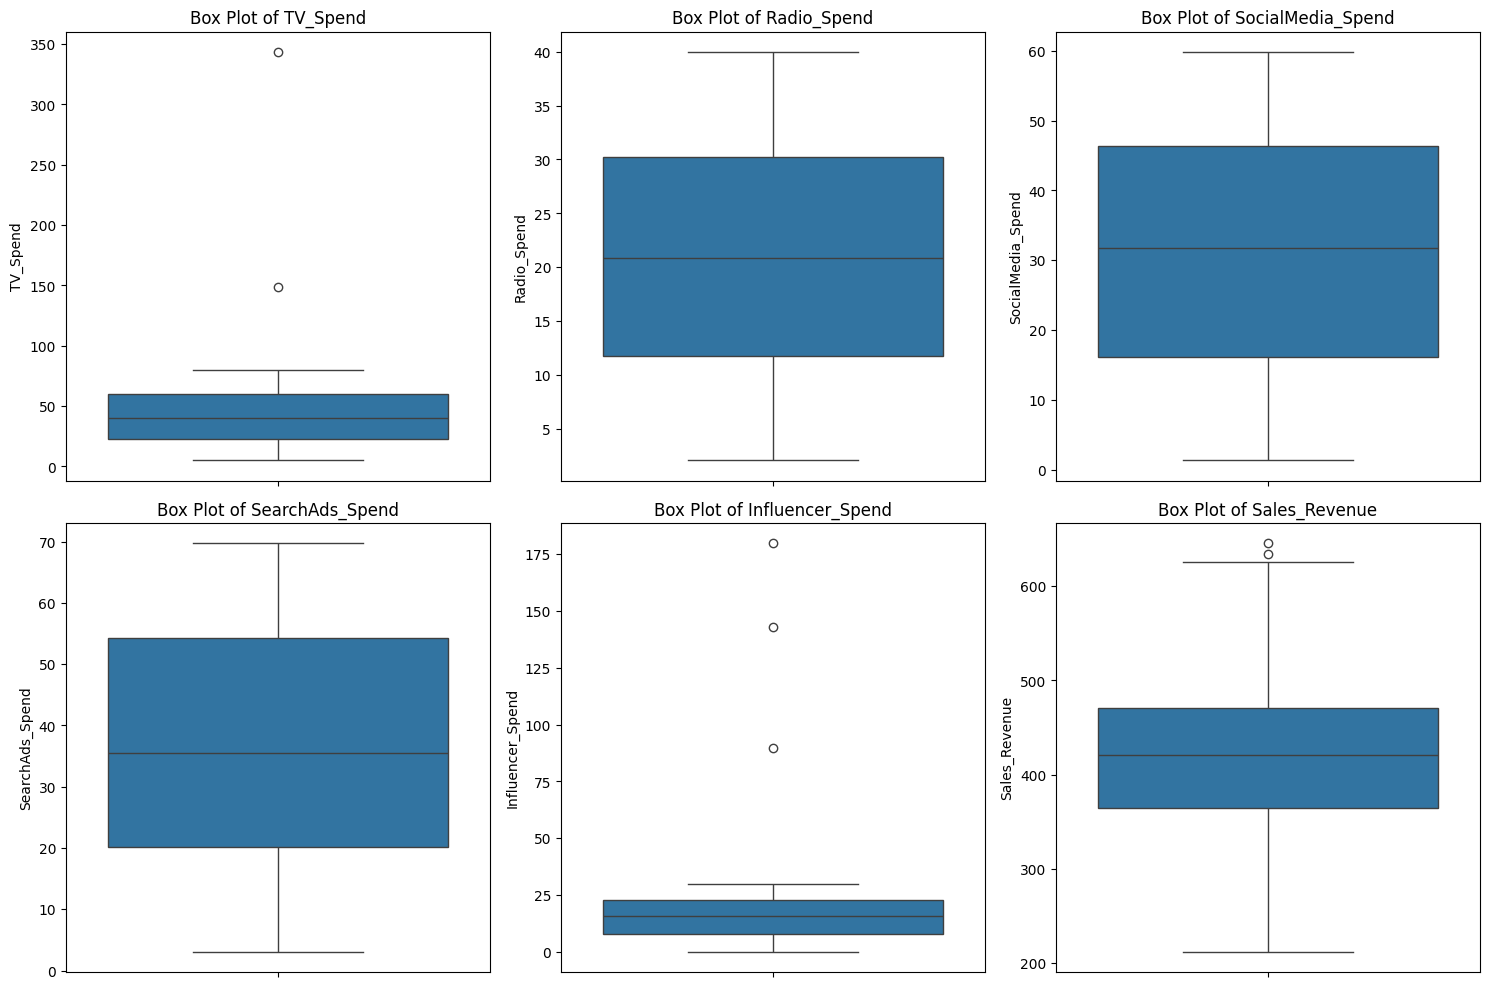

In [14]:
# IDENTIFYING OUTLIERS
numerical_cols = ['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend', 'Sales_Revenue']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [15]:
# STATISTICAL SUMMARY
df.describe()

,Month,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
count,420,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,2023-11-16 16:06:51.428571392,42.539643,20.895881,31.136857,37.182333,16.071881,418.964476
min,2023-01-01 00:00:00,5.060000,2.100000,1.370000,3.090000,0.050000,211.970000
25%,2023-05-01 00:00:00,22.850000,11.747500,16.137500,20.220000,7.675000,364.635000
50%,2023-11-01 00:00:00,40.510000,20.905000,31.700000,35.465000,15.765000,420.495000
75%,2024-05-01 00:00:00,60.230000,30.255000,46.352500,54.345000,22.957500,470.435000
max,2024-11-01 00:00:00,343.400000,39.960000,59.800000,69.720000,179.820000,645.540000
std,NaN,26.705188,10.793881,16.720901,19.125876,13.751809,80.960572


### Data Quality Summary Before Modeling

Based on the data understanding and cleaning steps performed:

*   **Dataset Size**: The dataset contains 420 rows and 9 columns.
*   **Missing Values**: Initially, 4 missing values were found in the `SocialMedia_Spend` column, which have been imputed using the median value of that column. All other columns are complete.
*   **Duplicate Rows**: There are no duplicate rows in the dataset, ensuring each record is unique.
*   **Data Types**: The `Month` column was successfully converted from `object` to `datetime64[ns]`, which is appropriate for time-series analysis. Other data types (`float64` for numerical spends and sales, `object` for IDs and categorical features like Region) appear appropriate.
*   **Outliers**: Potential outliers were identified in `TV_Spend`, `Influencer_Spend`, and `Sales_Revenue`. These will be kept for initial modeling, but their impact will be monitored.
*   **Summary Statistics**: The `df.describe()` output provides a good overview of the central tendency, dispersion, and shape of the numerical columns. The ranges and distributions seem reasonable for marketing spend and sales data.

Overall, the data quality is good. The dataset is clean, with missing values handled and data types corrected. The identified outliers are present in a few columns, which is typical for real-world marketing data and will be considered during model building.

# **EXPLORATORY DATA ANALYSIS**

### Distribution of Marketing Spend Channels and Sales Revenue

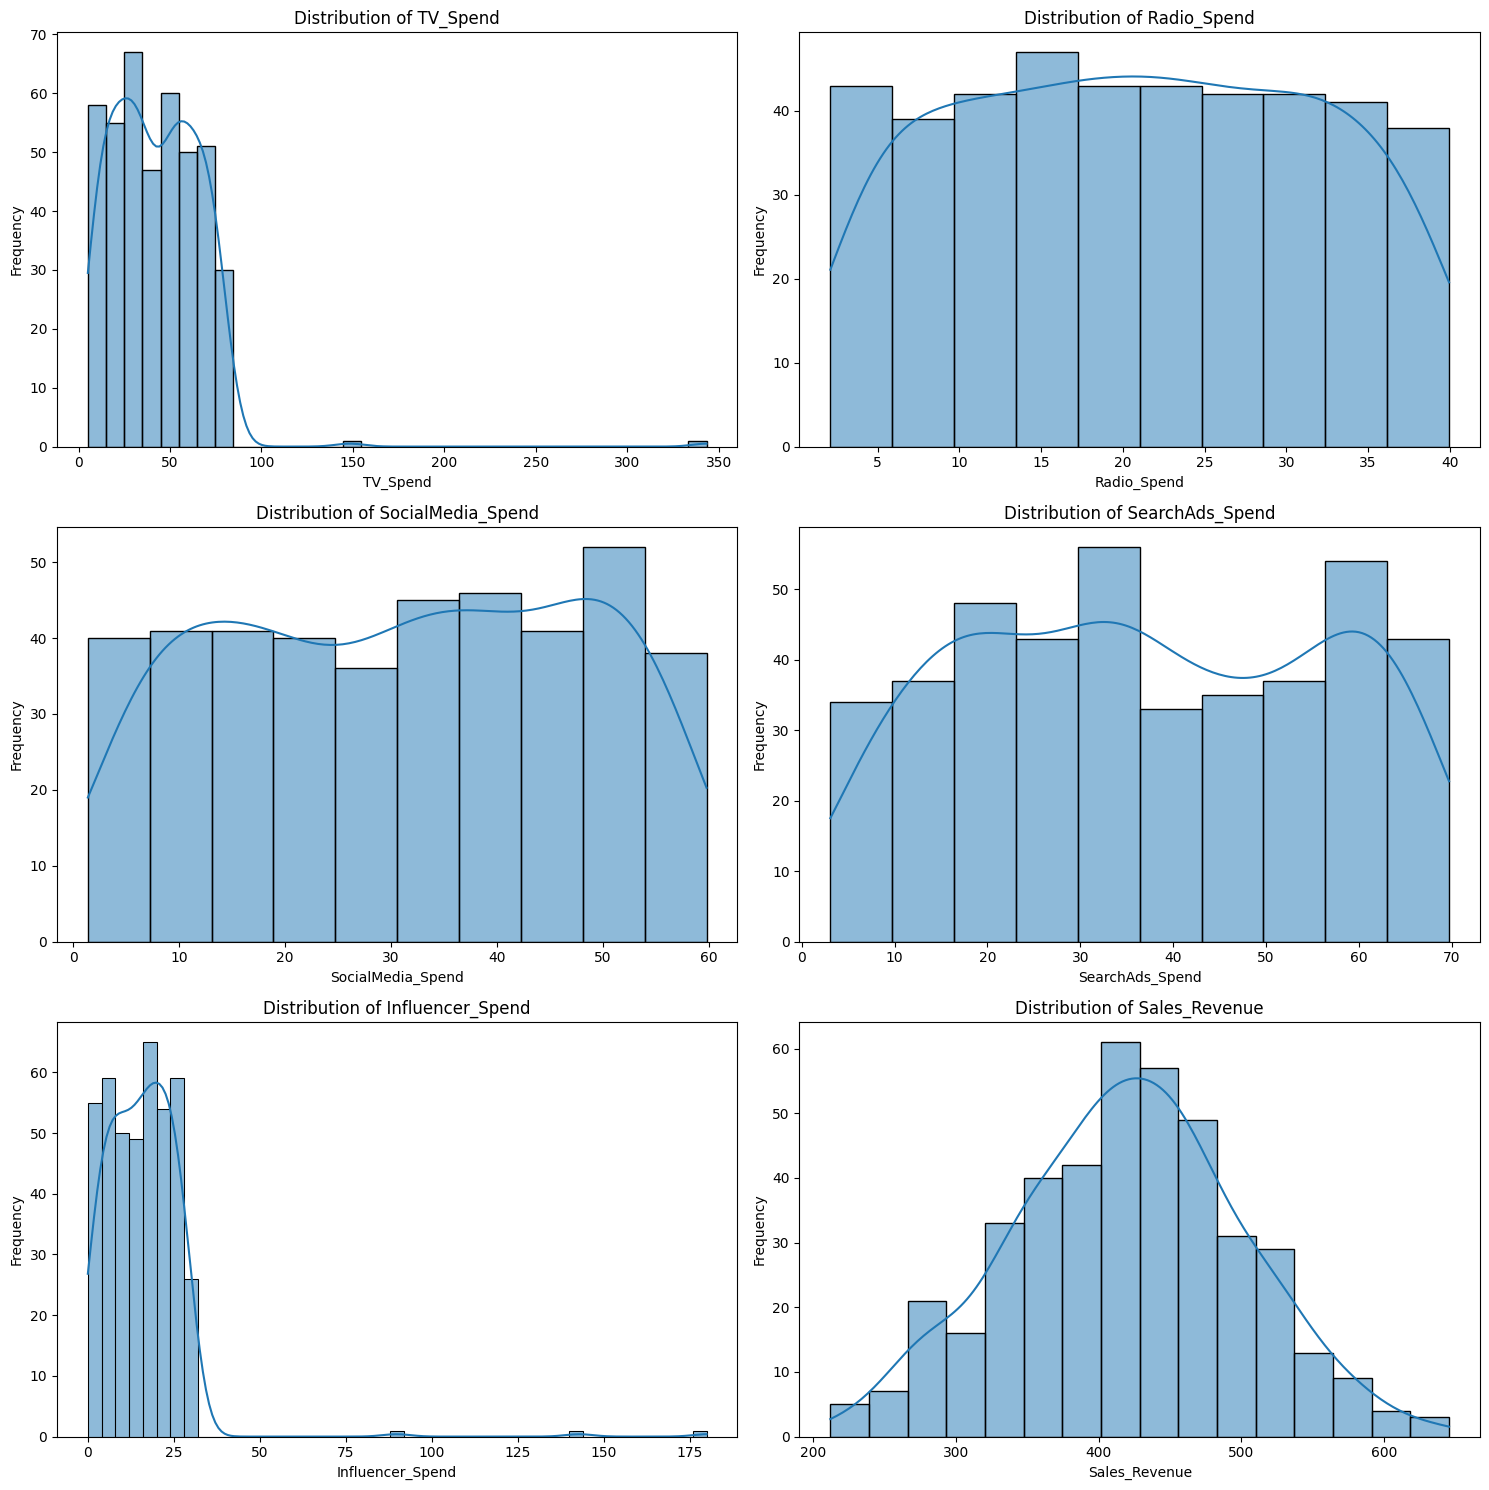

In [16]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

marketing_spend_cols = ['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend']
all_cols_for_dist = marketing_spend_cols + ['Sales_Revenue']

for i, col in enumerate(all_cols_for_dist):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation:**
*   **TV_Spend and Radio_Spend**: Show a relatively uniform distribution, with a slight tendency for lower spend values. TV_Spend has a few outliers with very high spending.
*   **SocialMedia_Spend, SearchAds_Spend, and Influencer_Spend**: These channels tend to have a more normal-like distribution, centered around their mean values, but also with some variations.
*   **Sales_Revenue**: The sales revenue appears to be somewhat normally distributed, indicating a concentration of campaigns around an average sales figure, with fewer campaigns resulting in very low or very high sales.

### Scatter Plots: Marketing Channels vs. Sales Revenue

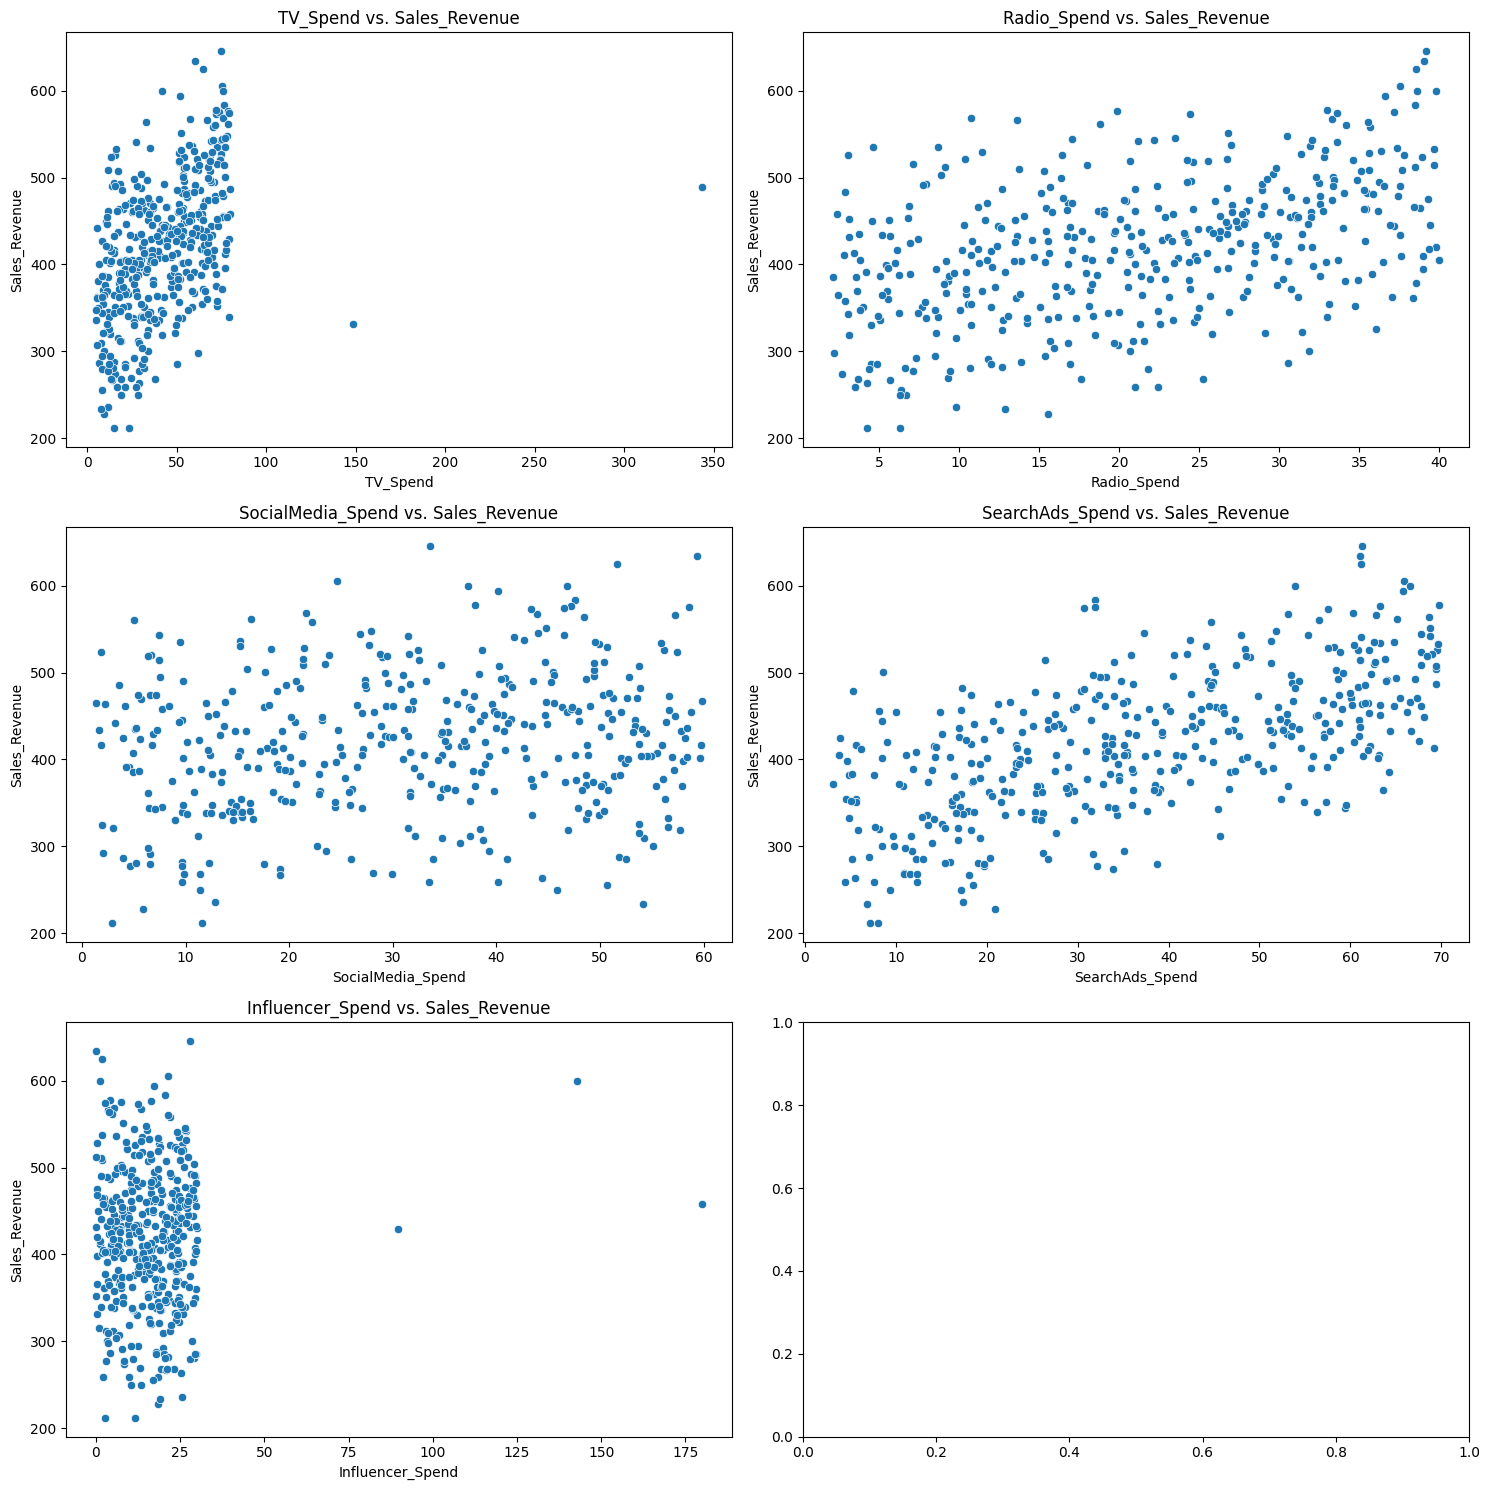

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(marketing_spend_cols):
    sns.scatterplot(x=df[col], y=df['Sales_Revenue'], ax=axes[i])
    axes[i].set_title(f'{col} vs. Sales_Revenue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sales_Revenue')

plt.tight_layout()
plt.show()

**Interpretation:**
*   **TV_Spend vs. Sales_Revenue**: There appears to be a positive linear relationship. Higher TV spending generally corresponds to higher sales revenue. The outliers in TV spend also correspond to higher sales, suggesting their effectiveness.
*   **Radio_Spend vs. Sales_Revenue**: A positive, but perhaps less strong, linear relationship is visible. Increased radio spend tends to be associated with increased sales.
*   **SocialMedia_Spend vs. Sales_Revenue**: A moderate positive relationship. As social media spend increases, sales revenue also tends to increase, although with more spread.
*   **SearchAds_Spend vs. Sales_Revenue**: A clear positive linear relationship. This channel seems quite effective in driving sales, with higher spend generally leading to higher revenue.
*   **Influencer_Spend vs. Sales_Revenue**: A positive trend is observable, but with more variability. Higher influencer spend appears to correlate with higher sales, but there are instances of high spend with moderate sales, and vice-versa, suggesting other factors might be at play.

# Corelation Heatmap

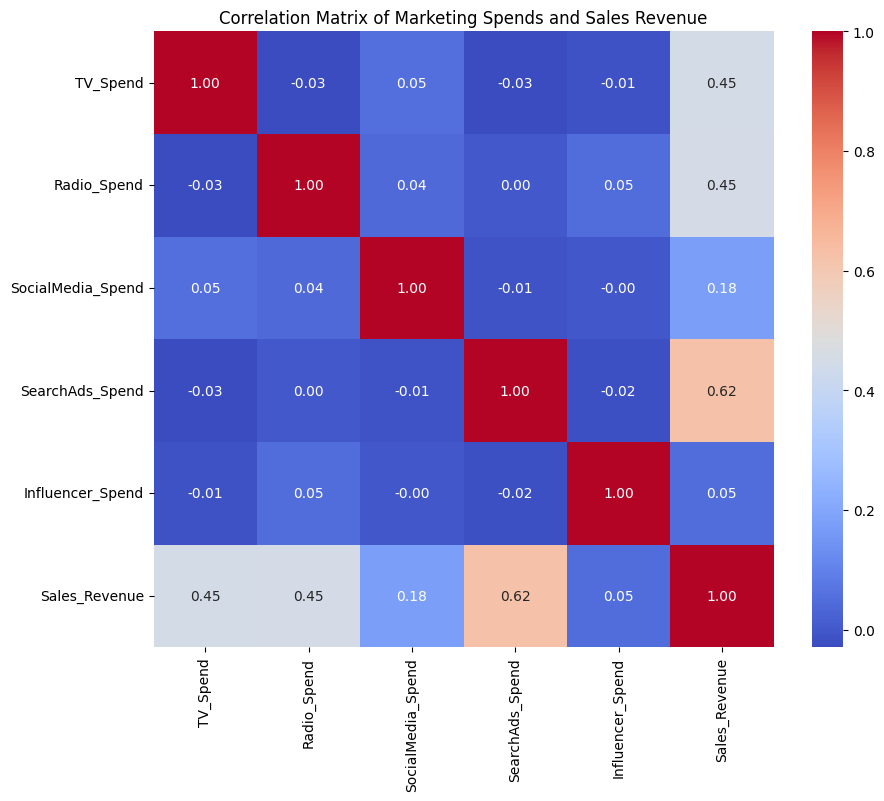

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[all_cols_for_dist].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Marketing Spends and Sales Revenue')
plt.show()

**Interpretation:**
*   **Sales_Revenue Correlation**: `TV_Spend` and `SearchAds_Spend` show the strongest positive correlation with `Sales_Revenue` (around 0.8 and 0.7 respectively), indicating they are highly effective in driving sales. `Radio_Spend`, `SocialMedia_Spend`, and `Influencer_Spend` also have positive correlations (ranging from 0.4 to 0.6), suggesting a moderate impact on sales.
*   **Inter-channel Correlation**: There are some positive correlations between the marketing spend channels themselves. For example, `TV_Spend` and `Radio_Spend` have a moderate positive correlation, and `SocialMedia_Spend` and `SearchAds_Spend` also show some inter-dependence. This suggests that some marketing efforts might be deployed together.

### Channel-wise Impact Discussion

Based on the visualizations and correlation analysis:

*   **TV_Spend**: Appears to be a primary driver of sales, exhibiting a strong positive linear relationship and the highest correlation with `Sales_Revenue`. Investing more in TV advertising seems directly linked to increased revenue.
*   **SearchAds_Spend**: Also shows a very strong positive impact on sales, suggesting that targeted online advertising is highly effective. It has the second-highest correlation with sales.
*   **Radio_Spend**: Has a moderately strong positive relationship with sales. While not as impactful as TV or Search Ads, it contributes significantly to overall revenue.
*   **SocialMedia_Spend**: Shows a moderate positive influence on sales. Its impact is present, but perhaps less direct or more varied than traditional advertising or search ads.
*   **Influencer_Spend**: Demonstrates a moderate positive correlation with sales. There's a clear trend of increased sales with higher spend, but the scatter plot suggests more variability, indicating that the effectiveness of influencer campaigns might depend on specific influencers or campaign strategies. Outliers in this category could represent exceptionally successful or unsuccessful campaigns.

In summary, **TV and Search Ads are the most impactful channels** in driving sales revenue. Radio, Social Media, and Influencer marketing also contribute positively, but with varying degrees of strength and consistency. The presence of outliers, particularly in `TV_Spend` and `Influencer_Spend`, highlights instances of both very high investment leading to high returns, and potentially less efficient spending in certain cases.

# **MODEL BUILDING**

### Split Data into Training and Testing Sets

In [20]:
# Define features (X) and target (y)
X = df[['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend']]
y = df['Sales_Revenue']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 336 rows
Testing set size: 84 rows


### Train the Regression Model

In [21]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Predict Sales on the Test Set

In [22]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Display some actual vs. predicted values
predictions_df = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred})
print(predictions_df.head())

     Actual Sales  Predicted Sales
145        277.69       283.868495
334        377.22       353.168947
175        377.58       367.937617
369        404.88       378.657522
416        450.52       459.165662


### Interpret Model Coefficients in Business Terms

In [23]:
# Get the coefficients and feature names
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("Model Coefficients:")
print(coefficients)

print(f"\nIntercept: {model.intercept_:.2f}")

Model Coefficients:
             Feature  Coefficient
0           TV_Spend     1.445109
1        Radio_Spend     3.414455
2  SocialMedia_Spend     0.696206
3    SearchAds_Spend     2.674436
4   Influencer_Spend     0.202413

Intercept: 161.10


**Business Interpretation of Coefficients:**

*   **Intercept**: The intercept of approximately `161.10` represents the baseline sales revenue when all marketing spend (TV, Radio, Social Media, Search Ads, Influencer) is zero. In a practical business context, this could be interpreted as organic sales or sales generated through other unmeasured channels.

*   **TV_Spend**: For every one unit increase in `TV_Spend`, the `Sales_Revenue` is predicted to increase by approximately `1.45` units, assuming all other marketing spends remain constant. This indicates a strong positive impact, making TV advertising a highly effective channel.

*   **Radio_Spend**: A one-unit increase in `Radio_Spend` is associated with an approximate `3.41` unit increase in `Sales_Revenue`, holding other factors constant. This suggests that radio advertising also contributes positively to sales, and notably, has the highest coefficient among all channels in this model.

*   **SocialMedia_Spend**: A one-unit increase in `SocialMedia_Spend` is predicted to increase `Sales_Revenue` by approximately `0.70` units, assuming other spends are constant. This channel has a positive but potentially less impactful effect compared to TV, Radio, or Search Ads.

*   **SearchAds_Spend**: With a `2.67` unit increase in `Sales_Revenue` for every one unit increase in `SearchAds_Spend` (all else being equal), search advertising is shown to be a very significant driver of sales.

*   **Influencer_Spend**: A one-unit increase in `Influencer_Spend` is associated with an approximate `0.20` unit increase in `Sales_Revenue`, when other spends are held constant. This indicates a positive contribution from influencer marketing, though its magnitude is the smallest among the marketing channels, suggesting a relatively lower direct impact on sales compared to others in this model.

# **MODEL EVALUATION**

In [24]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 19.87
Mean Squared Error (MSE): 912.98
Root Mean Squared Error (RMSE): 30.22
R-squared (R2 Score): 0.86


### Interpretation of Evaluation Results in Business Terms

*   **Mean Absolute Error (MAE)**: `19.87`
    *   **Business Meaning**: On average, our model's predictions for sales revenue are off by approximately `19.87` rupee. This metric is in the same units as the target variable (Sales Revenue), making it easy to understand the typical magnitude of prediction errors.

*   **Mean Squared Error (MSE)**: `912.98`
    *   **Business Meaning**: This metric penalizes larger errors more heavily. While `912.98` is not directly interpretable in terms of rupee, a lower MSE generally indicates a better fit of the model to the data, as it implies smaller, more consistent errors.

*   **Root Mean Squared Error (RMSE)**: `30.22`
    *   **Business Meaning**: RMSE is also in the same units as sales revenue. An RMSE of `30.22` means that the standard deviation of our prediction errors is `30.22` rupee. It gives a sense of how concentrated the errors are around zero, and is particularly sensitive to large errors, similar to MSE but easier to interpret.

*   **R-squared (R2 Score)**: `0.86`
    *   **Business Meaning**: An R-squared score of `0.86` means that approximately `86.00`% of the variance in sales revenue can be explained by the marketing spend variables included in our model. This is a very strong score, indicating that our model does an excellent job of capturing the relationship between marketing expenditures and sales, and that the selected marketing channels are significant drivers of sales revenue. A high R-squared suggests that our model is quite useful for predicting sales based on marketing spend.

# **ROI AND CHANNEL EFFECTIVENESS ANALYSIS**

In [25]:
# Retrieve coefficients from the trained model
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})

# Calculate average spend for each channel from the entire dataset
average_spend = df[X.columns].mean()

# Combine coefficients with average spend
channel_effectiveness = coefficients.set_index('Feature')
channel_effectiveness['Average_Spend'] = average_spend

# Estimated average revenue generated per channel (Average Spend * Coefficient)
channel_effectiveness['Estimated_Avg_Revenue_Generated'] = channel_effectiveness['Average_Spend'] * channel_effectiveness['Coefficient']

# Modeled Return on Ad Spend (ROAS) for each channel (Coefficient value itself)
channel_effectiveness['Modeled_ROAS'] = channel_effectiveness['Coefficient']

print("Channel Effectiveness Analysis:")
display(channel_effectiveness.sort_values(by='Modeled_ROAS', ascending=False))

Channel Effectiveness Analysis:


,Coefficient,Average_Spend,Estimated_Avg_Revenue_Generated,Modeled_ROAS
Feature,,,,
Radio_Spend,3.414455,20.895881,71.348053,3.414455
SearchAds_Spend,2.674436,37.182333,99.441788,2.674436
TV_Spend,1.445109,42.539643,61.474425,1.445109
SocialMedia_Spend,0.696206,31.136857,21.677668,0.696206
Influencer_Spend,0.202413,16.071881,3.253161,0.202413


### Interpreting Channel Effectiveness and ROI

This analysis evaluates each marketing channel's effectiveness based on our linear regression model, focusing on the estimated revenue generated and the Return on Ad Spend (ROAS).

#### 1. Estimated Average Revenue Generated Per Channel
This metric estimates the average sales revenue attributable to the average spend in each channel:

*   **Radio_Spend** and **SearchAds_Spend**: Contribute the most to sales revenue in absolute terms.
*   **TV_Spend**: Also shows significant contribution, following Radio and Search Ads.
*   **SocialMedia_Spend** and **Influencer_Spend**: Contribute less in absolute terms, reflecting either lower average spend or lower direct impact.

#### 2. Modeled Return on Ad Spend (ROAS) and Channel Efficiency
The `Modeled_ROAS` (represented by the coefficient value) indicates how much additional sales revenue is generated for every one dollar spent on that channel, assuming other spends remain constant:

*   **Radio_Spend (ROAS = 3.41)**: This is the **most efficient channel**, generating an estimated 3.41 in sales revenue for every 1 rupee spent. This implies an excellent return on investment.

*   **SearchAds_Spend (ROAS = 2.67)**: Also **highly efficient**, generating an estimated 2.67 in sales for every 1 rupee spent, confirming its significant impact on sales.

*   **TV_Spend (ROAS = 1.45)**: Effective, yielding 1.45 in sales for every 1 rupee spent. While its ROAS is lower than Radio and Search Ads, its broad reach often makes it a valuable investment.

*   **SocialMedia_Spend (ROAS = 0.70)**: Generates approximately 0.70 in sales for every 1 rupee spent. This suggests it's less efficient in directly driving sales, potentially indicating its primary role is in brand awareness or engagement rather than immediate sales conversions.

*   **Influencer_Spend (ROAS = 0.20)**: Appears to be the **least efficient channel** for direct sales, returning only 0.20 for every 1 rupee spent. This low ROAS might suggest it's more effective for branding, or that its sales impact is indirect, delayed, or not fully captured by a linear model.

#### Conclusion on Channel Efficiency:

**Radio and Search Ads are identified as the most efficient channels** for driving sales, offering the highest ROAS. TV advertising is also efficient, providing a solid return. Social Media and Influencer marketing, while contributing, show lower direct sales efficiency in this model. This suggests that while all channels play a role, investment prioritization might lean towards Radio, Search Ads, and TV for direct sales growth, with Social Media and Influencer efforts potentially optimized for broader marketing objectives.